In [4]:
%pip install gurobipy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Layer, Concatenate
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.optimizers import Adam

# Data Prep


In [6]:
data_23_24 = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/FantasyGo/FPL%20predictors/with%20new%20features/data/joint/23-24/merged_player_data.csv')
data_23_24['player_team']

# data_23_24 = pd.read_csv('../FPL predictors/with new features/data/joint/23-24/merged_player_data.csv') # data/joint/23-24/merged_player_data.csv')

,player_team
0,West Ham United
1,West Ham United
2,West Ham United
3,West Ham United
4,West Ham United
...,...
11042,Chelsea
11043,Chelsea
11044,Chelsea
11045,Chelsea


In [7]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

cols = [ 'position',  'creativity','ict_index', 'influence','selected',  'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home',
        'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh', 'whd', 'wha', 'event', 'team', 'opponent_team','fpl_name', 'xP', # 'total_points',

        #  'position', 'expected_goals_conceded', 'creativity','ict_index', 'influence','selected',  'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home',
        # 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'pts_bps', 'whh', 'whd', 'wha', 'team_creativity', 'team_influence',
        # 'team_threat', 'team_expected_goals', 'team_expected_assists', 'team_expected_goal_involvements', 'team_expected_goals_conceded', 'team_goals_conceded', 'team_goals_scored',
        #  'team_shots', 'team_key_passes', 'team_npg', 'team_npxG', 'team_value', 'team_ict_index', 'team_selected','team_transfers_in', 'team_transfers_out', 'team_whh', 'team_whd',
        #  'team_wha', 'total_points', 'event', 'fpl_name', # 'xP',

        'opponent_xgc_3', 'opponent_xgc_5', 'opponent_gc_3', 'opponent_gc_5', 'opponent_goals_scored_3', 'opponent_goals_scored_5', 'team_was_home', 'opponent_ict', 'opponent_xG',
        'opponent_xA', 'opponent_goals_scored', 'opponent_shots', 'opponent_npxG', 'opponent_value', 'opponent_whh', 'opponent_whd', 'opponent_wha', 'opponent_difficulty',

        'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
        'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
        'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1',  'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',
        'xP_1',

        'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
        'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
        'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3',  'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',
        'xP_3',

        'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
        'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
        'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5',  'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',
        'xP_5',

        ]


In [8]:
play_data = data_23_24.copy()


play_data['gw'] = play_data['event']
play_data['team'] = play_data['player_team']
play_data['opponent_team'] = play_data.apply(lambda row: row['a_team'] if row['was_home'] == 1 else row['h_team'], axis=1)
play_data[['h_team', 'a_team', 'was_home', 'team', 'opponent_team', 'player_team', 'gw', 'round']]


sum_features = [
    'creativity', 'influence', 'threat',
    'expected_goals_1', 'expected_assists_1', 'expected_goal_involvements_1',
    'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1',
    'shots_1', 'key_passes_1', 'npg_1', 'npxG_1',
]

mean_features = [
    'value', 'ict_index', 'selected', 'transfers_in', 'transfers_out'
]

# max_features = [
#     'minutes_1', 'influence'
# ]

identity_features = [
    'whh', 'whd', 'wha',    # bookmaker odds
    'was_home',
    'opponent_team'
]

team_df = play_data.groupby(['team', 'gw']).agg({
    **{f: 'sum' for f in sum_features},
    **{f: 'mean' for f in mean_features},
    # **{f: 'max' for f in max_features},
    **{f: 'first' for f in identity_features}
}).reset_index()

for col in ['expected_goals_conceded_1','goals_conceded_1','goals_scored_1']:
    team_df[f'{col}_3'] = team_df.groupby('team')[col].rolling(3, min_periods=1).mean().reset_index(0, drop=True)
    team_df[f'{col}_5'] = team_df.groupby('team')[col].rolling(5, min_periods=1).mean().reset_index(0, drop=True)


team_df = team_df.rename(columns={
    'creativity': 'team_creativity',
    'influence': 'team_influence',
    'threat': 'team_threat',
    'expected_goals_1': 'team_expected_goals',
    'expected_assists_1': 'team_expected_assists',
    'expected_goal_involvements_1': 'team_expected_goal_involvements',
    'expected_goals_conceded_1': 'team_expected_goals_conceded',
    'goals_conceded_1': 'team_goals_conceded',
    'goals_scored_1': 'team_goals_scored',
    'shots_1': 'team_shots',
    'attempted_passes_1': 'team_attempted_passes',
    'key_passes_1': 'team_key_passes',
    'npg_1': 'team_npg',
    'npxG_1': 'team_npxG',
    'value': 'team_value',
    'ict_index': 'team_ict_index',
    'selected': 'team_selected',
    'transfers_in': 'team_transfers_in',
    'transfers_out': 'team_transfers_out',
    'whh': 'team_whh',
    'whd': 'team_whd',
    'wha': 'team_wha',
    'was_home': 'team_was_home',
    'expected_goals_conceded_1_3': 'team_expected_goals_conceded_3',
    'expected_goals_conceded_1_5': 'team_expected_goals_conceded_5',
    'goals_conceded_1_3': 'team_goals_conceded_3',
    'goals_conceded_1_5': 'team_goals_conceded_5',
    'goals_scored_1_3': 'team_goals_scored_3',
    'goals_scored_1_5': 'team_goals_scored_5',

    })


team_df = team_df.rename(columns={
    'creativity': 'team_creativity',
    'influence': 'team_influence',
    'threat': 'team_threat',
    'expected_goals_1': 'team_expected_goals',
    'expected_assists_1': 'team_expected_assists',
    'expected_goal_involvements_1': 'team_expected_goal_involvements',
    'expected_goals_conceded_1': 'team_expected_goals_conceded',
    'goals_conceded_1': 'team_goals_conceded',
    'goals_scored_1': 'team_goals_scored',
    'shots_1': 'team_shots',
    'attempted_passes_1': 'team_attempted_passes',
    'key_passes_1': 'team_key_passes',
    'npg_1': 'team_npg',
    'npxG_1': 'team_npxG',
    'value': 'team_value',
    'ict_index': 'team_ict_index',
    'selected': 'team_selected',
    'transfers_in': 'team_transfers_in',
    'transfers_out': 'team_transfers_out',
    'whh': 'team_whh',
    'whd': 'team_whd',
    'wha': 'team_wha',
    'was_home': 'team_was_home',
    'expected_goals_conceded_1_3': 'team_expected_goals_conceded_3',
    'expected_goals_conceded_1_5': 'team_expected_goals_conceded_5',
    'goals_conceded_1_3': 'team_goals_conceded_3',
    'goals_conceded_1_5': 'team_goals_conceded_5',
    'goals_scored_1_3': 'team_goals_scored_3',
    'goals_scored_1_5': 'team_goals_scored_5',

    })

opponent_stats = team_df[['team', 'gw','team_ict_index', 'team_expected_goals', 'team_expected_assists', 'team_goals_scored', 'team_shots', 'team_npxG', 'team_value',
                          'team_whh', 'team_whd', 'team_wha', 'team_expected_goals_conceded_3', 'team_expected_goals_conceded_5', 'team_goals_conceded_3', 'team_goals_conceded_5',
                          'team_goals_scored_3', 'team_goals_scored_5']].rename(

                columns={'team': 'opponent_team', 'team_ict_index':'opponent_ict','team_expected_goals': 'opponent_xG', 'team_expected_assists': 'opponent_xA',
                        'team_goals_scored': 'opponent_goals_scored', 'team_shots': 'opponent_shots', 'team_npxG': 'opponent_npxG', 'team_value': 'opponent_value',
                        'team_whh': 'opponent_whh', 'team_whd': 'opponent_whd', 'team_wha': 'opponent_wha', 'team_expected_goals_conceded_3': 'opponent_xgc_3',
                        'team_expected_goals_conceded_5': 'opponent_xgc_5', 'team_goals_conceded_3': 'opponent_gc_3', 'team_goals_conceded_5': 'opponent_gc_5',
                        'team_goals_scored_3': 'opponent_goals_scored_3', 'team_goals_scored_5': 'opponent_goals_scored_5'
                        })

# opponent_stats
# 2. Merge this back into the original dataframe matching on 'opponent_team' and 'gw'
team_df = team_df.merge(opponent_stats, on=['opponent_team', 'gw'], how='left')

final_df = play_data.merge(team_df, on=['opponent_team', 'team','gw'], how='left')

# ODI = Probability of Draw + Probability of Away Win (assuming player's team is Home odds)
# A high ODI means a tough fixture (Player's team is less likely to win).
# ODI = Probability of Draw + Probability of Home Win (assuming player's team is Away odds)
# A high ODI means a tough fixture (Player's team is more likely to win).
final_df['opponent_difficulty'] = final_df.apply(
    lambda row: (row['whd'] + row['wha'])
    if row['player_team'] == row['h_team']
    else (row['whd'] + row['whh']),
    axis=1
)

# final_df['total_points']


# Functions


In [9]:
def prepare_fpl_data(data):
    data = data[cols]
    # These are the relevant columns inferred from the table header:
    feature_cols = [
        'creativity', 'expected_assists', 'expected_goal_involvements',
        'expected_goals', 'form', 'influence', 'ict_index', 'xP',
        'transfers_balance', 'value', 'was_home',
        'points_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5', 'xP_5'
    ]

    # The target variable is 'points' for the next gameweek (not explicitly in header, but
    # 'points' is usually the target, or 'xP' which is present here.
    # Let's use 'points_y' as the target for the next gameweek, but since that's not in the snippet,
    # we'll use 'xP' as a proxy for the current row's points, and assume the *next* # row's xP is the target for prediction.
    # Given the snapshot, we'll assume the model is predicting the current row's `points`.

    target_col = ['xP', 'fpl_name'] # Assuming 'points' is the column for the points scored in the Gameweek
    conditional_cols = ['whh', 'whd', 'wha']
    gameweek_col = 'event' # Assuming 'event' is the gameweek column
    GW_COL = 'event' # Assuming 'event' is the column for Gameweek (GW)
    POSITION_COL = 'position' # Categorical column that needs one-hot encoding
    M_COL = 'opponent_difficulty'


    # # --- Step 1: Handle Categorical Features (One-Hot Encoding) ---
    # df = pd.get_dummies(data, columns=[POSITION_COL], prefix=POSITION_COL, dummy_na=False)

    CATEGORICAL_COLS = [POSITION_COL, 'team', 'opponent_team'] # <--- EDITED: Now includes team and opponent_team
    df = pd.get_dummies(data, columns=CATEGORICAL_COLS, prefix=CATEGORICAL_COLS, dummy_na=False)

        # 2. Target Variable (Y)
    Y = df[target_col].fillna(0) #.values.astype(np.float32)

    # # 3. Input Features (X)
    # X_cols = [c for c in df.columns if c not in ['points', 'event', 'whh', 'whd', 'wha', 'Opponent_Difficulty']]
    # X = df[X_cols].fillna(0).values#.astype(np.float32)


    # 3. Input Features (X)
    EXCLUDE_COLS = [*target_col, GW_COL, M_COL] # + META_COLS_TO_IGNORE
    # Dynamically find the newly created position columns and include them in X_cols
    new_position_cols = [col for col in df.columns if col.startswith(f'{POSITION_COL}_')]

    # Ensure all original numerical features are included, and remove the categorical one
    X_cols = [c for c in df.columns if c not in EXCLUDE_COLS and c != POSITION_COL]

    # Add the newly created one-hot encoded columns
    X_cols.extend(new_position_cols)

    # Filter columns that might not exist after one-hot encoding or were missed in the list
    X_cols = [col for col in X_cols if col in df.columns]

    print('xP' in X_cols)
    # Convert the feature matrix to numpy array, forcing numeric type after one-hot encoding
    X = df[X_cols].fillna(0).values.astype(np.float32)



    # 4. Conditional Parameter (M)
    M = df['opponent_difficulty']#.values#.astype(np.float32).reshape(-1, 1)
    M = M.fillna(0).values.astype(np.float32)

    # 5. Gameweek for splitting
    GW = df['event'].values

    print(f"Data prepared. X shape: {X.shape}, M shape: {M.shape}, Y shape: {Y.shape}")
    print(f"Features used: {X_cols}")

    return X, M, Y, GW

In [10]:
def build_affine_pnn(input_dim_x, output_dim_y, hidden_units=128):
    """
    Builds the Affine Parametric Neural Network (AffinePNN) Model.
    """
    L2_REG = 0.001 # L2 regularization strength
    # Input for Features (X) and Conditional Parameter (M)
    X_input = Input(shape=(input_dim_x,), name='X_input')
    M_input = Input(shape=(1,), name='M_input') # The conditional parameter m

    # Initial Dense Layer (Standard)
    x = Dense(hidden_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(L2_REG), name='Dense_1')(X_input)

    # Affine Conditioning Block 1
    # Feeds the current features (x) and the conditional parameter (M)
    x = AffineConditioning(units=hidden_units, activation='relu', name='Affine_Cond_1')([x, M_input])

    # Standard Dense Layer
    x = Dense(hidden_units // 2, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(L2_REG), name='Dense_2')(x)

    # Affine Conditioning Block 2
    x = AffineConditioning(units=hidden_units // 2, activation='relu', name='Affine_Cond_2')([x, M_input])

    # Final Prediction Layer (Regression output for FPL points)
    output = Dense(output_dim_y, activation='linear', name='Output')(x)

    model = Model(inputs=[X_input, M_input], outputs=output, name='AffinePNN_FPL')
    return model


In [11]:
class AffineConditioning(Layer):
    """
    Custom Keras Layer implementing the core Affine Parametric Neural Network (AffinePNN) logic.

    The transformation is: z = s * x + b
    Where s (scale) and b (bias) are linear functions of the conditional parameter 'm' (Opponent Difficulty).
    s = phi * m + s0
    b = psi * m + b0

    phi, psi, s0, and b0 are the trainable weights.
    """
    def __init__(self, units, activation=None, **kwargs):
        super(AffineConditioning, self).__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        # input_shape is a list: [feature_input_shape, parameter_input_shape]
        feature_dim = input_shape[0][-1]

        # Trainable weights for the conditional parameter 'm' (Opponent Difficulty)
        # phi (for scaling m) and psi (for biasing m) are feature_dim x 1
        self.phi = self.add_weight(shape=(feature_dim,), initializer='glorot_uniform', trainable=True, name='phi')
        self.psi = self.add_weight(shape=(feature_dim,), initializer='glorot_uniform', trainable=True, name='psi')

        # Trainable weights for the non-conditional affine transformation
        # s0 (base scaling) and b0 (base bias) are feature_dim x 1
        self.s0 = self.add_weight(shape=(feature_dim,), initializer='zeros', trainable=True, name='s0')
        self.b0 = self.add_weight(shape=(feature_dim,), initializer='zeros', trainable=True, name='b0')

        self.built = True

    def call(self, inputs):
        # inputs is a list: [feature_input, parameter_input]
        x_in, m = inputs

        # 1. Expand 'm' to match feature dimensions
        # m has shape (batch_size, 1). We need (batch_size, feature_dim)
        m_expanded = tf.repeat(m, tf.shape(x_in)[-1], axis=-1)

        # 2. Calculate scaling vector 's' and biasing vector 'b'
        # s = phi * m + s0
        # b = psi * m + b0
        s = self.phi * m_expanded + self.s0
        b = self.psi * m_expanded + self.b0

        # 3. Apply the affine transformation (element-wise)
        # z = s * x_in + b
        x_out = s * x_in + b

        # 4. Apply activation function
        if self.activation is not None:
            return self.activation(x_out)
        return x_out

    def get_config(self):
        config = super(AffineConditioning, self).get_config()
        config.update({
            'units': self.units,
            'activation': tf.keras.activations.serialize(self.activation),
        })
        return config


# Models


## Predictors


### GW 36


In [13]:
def prep_prediction_data(df, gw):
  # Since I cannot load the HTML, I use the mock data function.
    # *** If you have the data in a CSV/Pandas DataFrame, replace the call below
    # *** with your actual data loading and preprocessing steps.
    # data_snippet_html = """... (provided HTML table) ..."""
  X_full, M_full, Y_full, GW_full = prepare_fpl_data(df)

  # --- Split Data into Train (GW <= gw) and Test (GW) ---
  GW_TRAIN_END = gw-1

  # Training Data
  train_mask = GW_full <= GW_TRAIN_END
  X_train, M_train, Y_train = X_full[train_mask], M_full[train_mask], Y_full[train_mask]

  Y_train_names = Y_train['fpl_name'].values
  Y_train = Y_train['xP'].values


  # Test Data (for prediction)
  test_mask = GW_full == GW_TRAIN_END + 1 # GW_full > GW_TRAIN_END
  X_test, M_test, Y_test = X_full[test_mask], M_full[test_mask], Y_full[test_mask]

  Y_test_names = Y_test['fpl_name'].values
  Y_test = Y_test['xP'].values


  print("-" * 50)
  print(f"Training on GW 1-{GW_TRAIN_END}: {X_train.shape[0]} samples")
  print(f"Predicting on GW {GW_TRAIN_END+1}-{np.max(GW_full)}: {X_test.shape[0]} samples")
  print("-" * 50)

  # --- Scaling ---
  # Scale Features (X)
  scaler_x = StandardScaler()
  X_train_scaled = scaler_x.fit_transform(X_train)
  X_test_scaled = scaler_x.transform(X_test)

  # Scale Conditional Parameter (M) - Standardize for better convergence
  scaler_m = StandardScaler()
  M_train_scaled = scaler_m.fit_transform(M_train.reshape(-1, 1))
  M_test_scaled = scaler_m.transform(M_test.reshape(-1, 1))

  # --- Model Definition and Training ---

  INPUT_DIM_X = X_train_scaled.shape[1]
  OUTPUT_DIM_Y = 1 # Predicting a single point value

  return INPUT_DIM_X, OUTPUT_DIM_Y


def predictor(model, INPUT_DIM_X, OUTPUT_DIM_Y):

  # 1. EVALUATE TEST SET PERFORMANCE using model.evaluate
  print("\nEvaluating test set performance...")
  test_results = model.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

  # The order of results corresponds to the metrics in model.compile: [loss, mae, mse, r_squared]
  # test_loss, test_mae, test_mse, test_r2 =
  #  test_results

  # Predict points for GW
  print('\nPredicting')
  Y_pred = model.predict([X_test_scaled, M_test_scaled]).flatten()


  # print('----'*5, Y_pred)

  # Combine results for evaluation (Mocked player IDs for display)
  results_df = pd.DataFrame({
      'Gameweek': GW_full[test_mask],
      'Actual_Points': Y_test,
      'Predicted_Points': Y_pred,
      'Opponent_Difficulty_m': M_test.flatten(),
      'Player_ID': Y_test_names# np.arange(len(Y_test)) # Mock player ID
  })

  # Calculate Mean Absolute Error (MAE) for the prediction period
  mae = np.mean(np.abs(Y_test - Y_pred))

  print("-" * 50)
  print(f"Prediction Results for GW 36-{np.max(GW_full)}:")
  print(f"Mean Absolute Error (MAE): {mae:.2f} points")
  print("-" * 50)
  print("Sample Predictions (Top 10):")
  print(results_df.sort_values(by='Predicted_Points', ascending=False).head(10).round(2).to_markdown(index=False))


  from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
  r2 = r2_score(Y_test, Y_pred)
  print("R²:", r2)

  mae = mean_absolute_error(Y_test, Y_pred)
  print("MAE:", mae)

  mse = mean_squared_error(Y_test, Y_pred)
  print("MSE:", mse)

  return results_df


In [23]:

INPUT_DIM_X, OUTPUT_DIM_Y = prep_prediction_data(final_df, 36)
affine_pnn = build_affine_pnn(INPUT_DIM_X, OUTPUT_DIM_Y, hidden_units=128)

# Using MSE as the loss function for regression
affine_pnn.compile(
    optimizer=Adam(learning_rate=0.0001, clipnorm=1.0),
    loss='mse',
    metrics=['mae', 'mse']
)

print("\nTraining AffinePNN model...")
history = affine_pnn.fit(
    [X_train_scaled, M_train_scaled],
    Y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1 # Set to 1 to see epoch progress
)
print("Training complete.")

# --- Prediction and Evaluation ---

False
Data prepared. X shape: (7665, 227), M shape: (7665,), Y shape: (7665, 2)
Features used: ['creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh', 'whd', 'wha', 'opponent_xgc_3', 'opponent_xgc_5', 'opponent_gc_3', 'opponent_gc_5', 'opponent_goals_scored_3', 'opponent_goals_scored_5', 'team_was_home', 'opponent_ict', 'opponent_xG', 'opponent_xA', 'opponent_goals_scored', 'opponent_shots', 'opponent_npxG', 'opponent_value', 'opponent_whh', 'opponent_whd', 'opponent_wha', 'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',

NameError: name 'X_train_scaled' is not defined

## GW 37


In [14]:
 # Since I cannot load the HTML, I use the mock data function.
  # *** If you have the data in a CSV/Pandas DataFrame, replace the call below
  # *** with your actual data loading and preprocessing steps.
  # data_snippet_html = """... (provided HTML table) ..."""
X_full, M_full, Y_full, GW_full = prepare_fpl_data(final_df)

# --- Split Data into Train (GW <= 36) and Test (GW 37) ---
GW_TRAIN_END = 36

# Training Data
train_mask = GW_full <= GW_TRAIN_END
X_train, M_train, Y_train = X_full[train_mask], M_full[train_mask], Y_full[train_mask]

Y_train_names = Y_train['fpl_name'].values
Y_train = Y_train['xP'].values


# Test Data (for prediction)
test_mask = GW_full == GW_TRAIN_END + 1 # GW_full > GW_TRAIN_END
X_test, M_test, Y_test = X_full[test_mask], M_full[test_mask], Y_full[test_mask]

Y_test_names = Y_test['fpl_name'].values
Y_test = Y_test['xP'].values


print("-" * 50)
print(f"Training on GW 1-{GW_TRAIN_END}: {X_train.shape[0]} samples")
print(f"Predicting on GW {GW_TRAIN_END+1}: {X_test.shape[0]} samples")
print("-" * 50)

# --- Scaling ---
# Scale Features (X)
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

# Scale Conditional Parameter (M) - Standardize for better convergence
scaler_m = StandardScaler()
M_train_scaled = scaler_m.fit_transform(M_train.reshape(-1, 1))
M_test_scaled = scaler_m.transform(M_test.reshape(-1, 1))

# --- Model Definition and Training ---

INPUT_DIM_X = X_train_scaled.shape[1]
OUTPUT_DIM_Y = 1 # Predicting a single point value

False
Data prepared. X shape: (11047, 242), M shape: (11047,), Y shape: (11047, 2)
Features used: ['creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh', 'whd', 'wha', 'opponent_xgc_3', 'opponent_xgc_5', 'opponent_gc_3', 'opponent_gc_5', 'opponent_goals_scored_3', 'opponent_goals_scored_5', 'team_was_home', 'opponent_ict', 'opponent_xG', 'opponent_xA', 'opponent_goals_scored', 'opponent_shots', 'opponent_npxG', 'opponent_value', 'opponent_whh', 'opponent_whd', 'opponent_wha', 'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_

In [15]:
affine_pnn = build_affine_pnn(INPUT_DIM_X, OUTPUT_DIM_Y, hidden_units=128)

# Using MSE as the loss function for regression
affine_pnn.compile(
    optimizer=Adam(learning_rate=0.0001, clipnorm=1.0),
    loss='mse',
    metrics=['mae', 'mse']
)

print("\nTraining AffinePNN model...")
history = affine_pnn.fit(
    [X_train_scaled, M_train_scaled],
    Y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1 # Set to 1 to see epoch progress
)
print("Training complete.")

# --- Prediction and Evaluation ---

# 1. EVALUATE TEST SET PERFORMANCE using model.evaluate
print("\nEvaluating test set performance...")
test_results = affine_pnn.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

# The order of results corresponds to the metrics in model.compile: [loss, mae, mse, r_squared]
# test_loss, test_mae, test_mse, test_r2 =
#  test_results

# Predict points for GW 36-38
print('\nPredicting')
Y_pred = affine_pnn.predict([X_test_scaled, M_test_scaled]).flatten()


# print('----'*5, Y_pred)

# Combine results for evaluation (Mocked player IDs for display)
results_df = pd.DataFrame({
    'Gameweek': GW_full[test_mask],
    'Actual_Points': Y_test,
    'Predicted_Points': Y_pred,
    'Opponent_Difficulty_m': M_test.flatten(),
    'Player_ID': Y_test_names# np.arange(len(Y_test)) # Mock player ID
})

# Calculate Mean Absolute Error (MAE) for the prediction period
mae = np.mean(np.abs(Y_test - Y_pred))

print("-" * 50)
print(f"Prediction Results for GW 37:")
print(f"Mean Absolute Error (MAE): {mae:.2f} points")
print("-" * 50)
print("Sample Predictions (Top 10):")
print(results_df.sort_values(by='Predicted_Points', ascending=False).head(10).round(2).to_markdown(index=False))

# results_df


Training AffinePNN model...
Epoch 1/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 10.2507 - mae: 2.3368 - mse: 10.0199 - val_loss: 6.6227 - val_mae: 1.8631 - val_mse: 6.4405
Epoch 2/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.8427 - mae: 1.9935 - mse: 7.6673 - val_loss: 4.3788 - val_mae: 1.4896 - val_mse: 4.2115
Epoch 3/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.7212 - mae: 1.5405 - mse: 4.5531 - val_loss: 2.8404 - val_mae: 1.1899 - val_mse: 2.6691
Epoch 4/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.1587 - mae: 1.2263 - mse: 2.9866 - val_loss: 2.1316 - val_mae: 1.0185 - val_mse: 1.9594
Epoch 5/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.5614 - mae: 1.0808 - mse: 2.3894 - val_loss: 1.7835 - val_mae: 0.9210 - val_mse: 1.6121
Epoch 6/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.0911 - mae: 0.9851 - mse: 1.9200 - val_loss: 1.5896 - val_mae: 0.8694 - val_mse: 1.4191
Epoch 7/50
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.9736 - 

In [16]:
results_df

,Gameweek,Actual_Points,Predicted_Points,Opponent_Difficulty_m,Player_ID
0,37,0.0,0.052425,0.474,Aaron Connolly
1,37,1.3,0.825289,0.474,Aaron Cresswell
2,37,1.4,0.736450,0.866,Aaron Wan-Bissaka
3,37,4.5,3.599287,0.323,Abdoulaye Doucouré
4,37,3.8,2.708187,0.510,Adam Smith
...,...,...,...,...,...
285,37,6.8,5.339066,0.727,Yoane Wissa
286,37,2.1,3.203735,0.774,Youri Tielemans
287,37,1.5,1.133074,0.323,Youssef Ramalho Chermiti
288,37,2.9,2.460036,0.301,Yves Bissouma


In [17]:
curr_data = final_df[final_df['event'] == 37].copy()
# curr_data['xP_pred'] = Y_pred

# players = curr_data[['fpl_id', 'fpl_name', 'team', 'value', 'position', 'xP_pred']].copy()
# players['player_id'] = list(range(len(players)))

# players.rename(columns={'fpl_name': 'name', 'value': 'price'}, inplace=True)
# players = players.reset_index(drop=True)

curr_data[['fpl_name', 'total_points']]

,fpl_name,total_points
5,Aaron Connolly,0
16,Aaron Cresswell,1
65,Aaron Wan-Bissaka,2
96,Abdoulaye Doucouré,8
157,Adam Smith,6
...,...,...
10913,Yoane Wissa,11
10946,Youri Tielemans,8
10962,Youssef Ramalho Chermiti,1
10990,Yves Bissouma,2


In [18]:
GW_TRAIN_END + 1

37

In [19]:
test_results['mse']
{
    'test_loss': test_results['loss'], 'test_mae': test_results['mae'] , 'test_mse': test_results['mse']
}

{'test_loss': 2.2706334590911865,
 'test_mae': 0.8638542294502258,
 'test_mse': 2.1438474655151367}

In [20]:
len(Y_test), len(Y_pred)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2 = r2_score(Y_test, Y_pred)
print("R²:", r2)

mae = mean_absolute_error(Y_test, Y_pred)
print("MAE:", mae)

mse = mean_squared_error(Y_test, Y_pred)
print("MSE:", mse)

R²: 0.7482776547244688
MAE: 0.8638542421316278
MSE: 2.143847559147538


### Plots


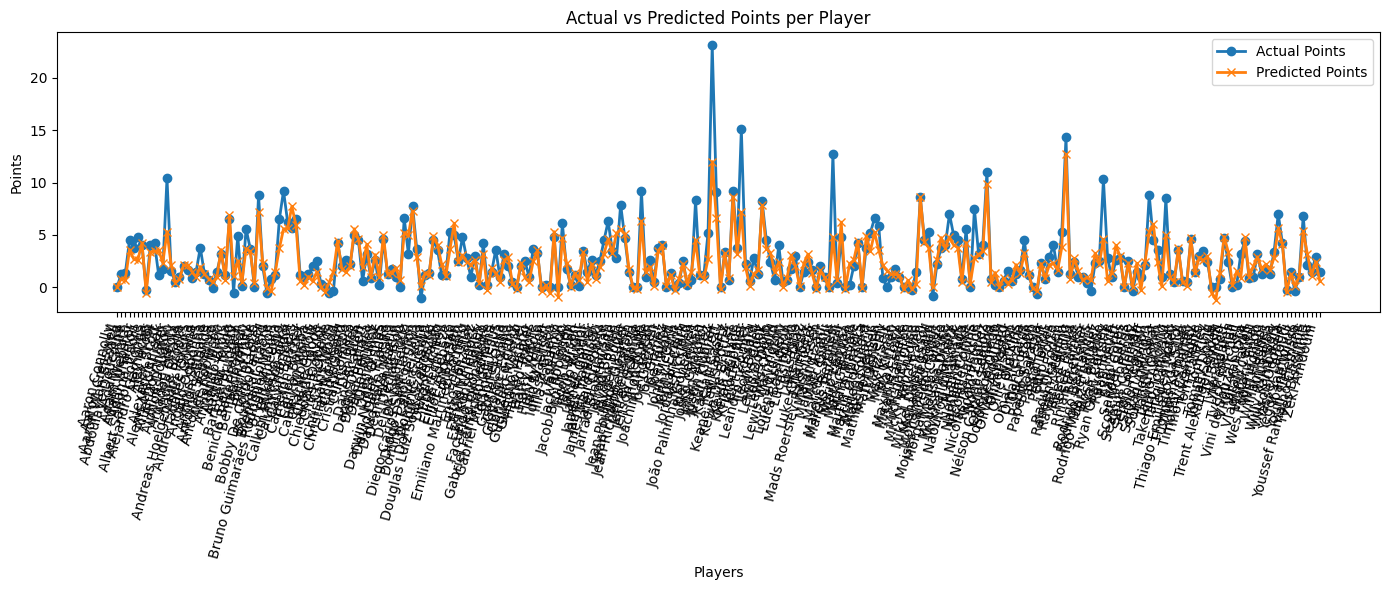

In [21]:
# Convert names to positions on x-axis
x = np.arange(len(Y_test_names))

plt.figure(figsize=(14, 6))

# Plot actual points
plt.plot(x, Y_test, marker='o', linewidth=2, label='Actual Points')

# Plot predicted points
plt.plot(x, Y_pred, marker='x', linewidth=2, label='Predicted Points')

# Improve readability
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player")
plt.legend()
plt.tight_layout()

plt.show()


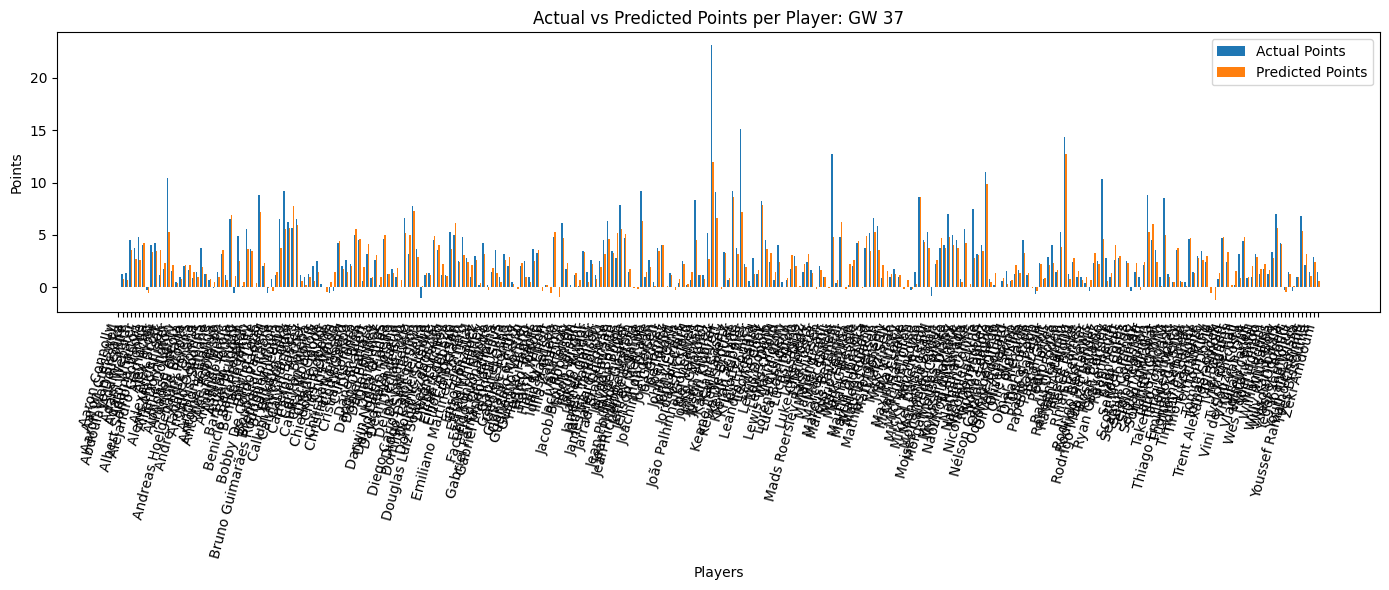

In [22]:
# Index positions for players
x = np.arange(len(Y_test_names))

# Width of each bar
width = 0.35

plt.figure(figsize=(14, 6))

# Bars
plt.bar(x - width/2, Y_test, width, label='Actual Points')
plt.bar(x + width/2, Y_pred, width, label='Predicted Points')

# Labels & formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player: GW 37")
plt.legend()

plt.tight_layout()
plt.show()


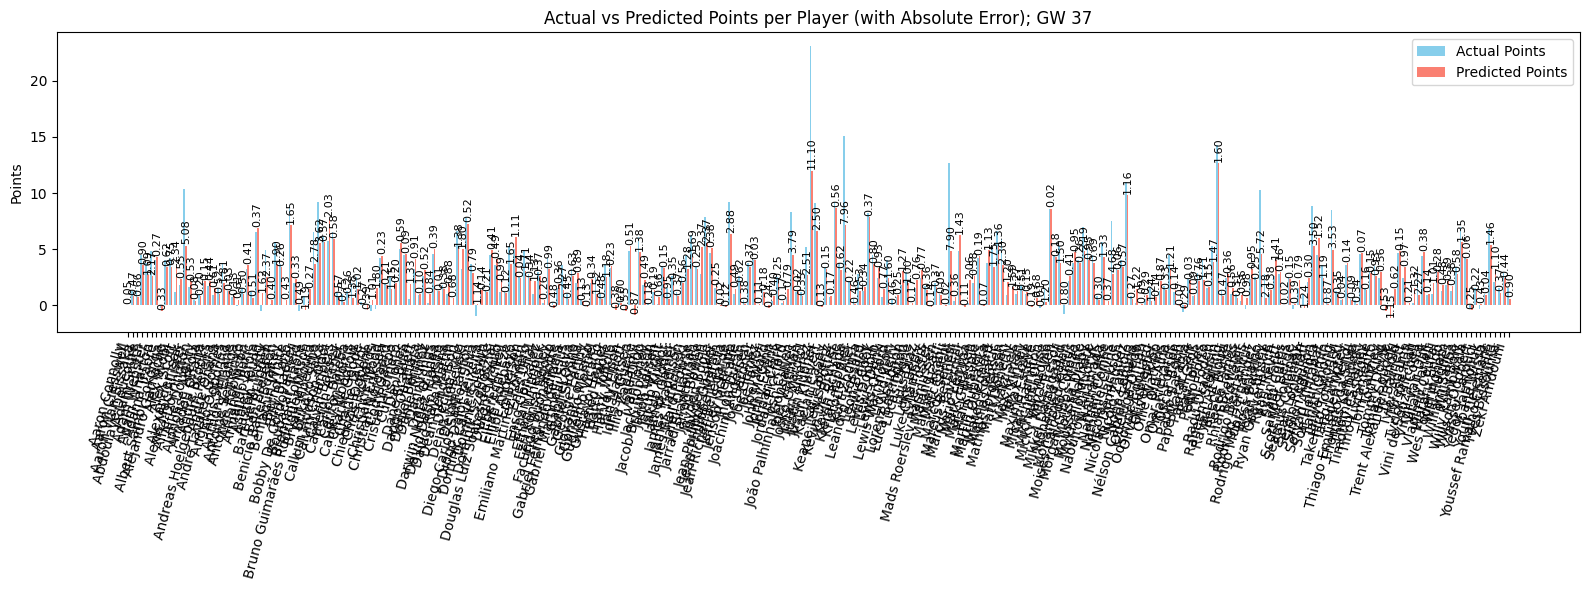

In [23]:
# Calculate absolute errors
errors = np.abs(Y_test - Y_pred)

# Index for players
x = np.arange(len(Y_test_names))
width = 0.35  # width of the bars

plt.figure(figsize=(16, 6))

# Plot Actual and Predicted points side-by-side
plt.bar(x - width/2, Y_test, width, label='Actual Points', color='skyblue')
plt.bar(x + width/2, Y_pred, width, label='Predicted Points', color='salmon')

# Annotate absolute errors on top of predicted bars
for i in range(len(Y_test_names)):
    plt.text(x[i] + width/2, Y_pred[i] + 0.1, f"{errors[i]:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

# Labels and formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (with Absolute Error); GW 37")
plt.legend()
plt.tight_layout()

plt.show()


### Optimization


#### IRL for HEPs


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import gurobipy as gp
from gurobipy import GRB

# Optional: torch_geometric for graph layers
try:
    from torch_geometric.nn import GATConv
    from torch_geometric.data import Data as GeoData
except Exception:
    GATConv = None
    GeoData = None

In [25]:
def make_dummy_players(n_players=100, seed=0):
    """Create a dummy players table with xP_pred, prices, position, team."""
    rng = np.random.RandomState(seed)
    # Ensure realistic player counts
    n_gk = int(n_players * 0.1)
    n_def = int(n_players * 0.3)
    n_mid = int(n_players * 0.4)
    n_fwd = n_players - n_gk - n_def - n_mid

    positions = (['GK'] * n_gk + ['DEF'] * n_def + ['MID'] * n_mid + ['FWD'] * n_fwd)[:n_players]
    teams = [f"Team{(i%20)+1}" for i in range(n_players)]
    price = np.round(rng.uniform(4.0, 12.5, size=n_players), 1)
    xP_pred = np.round(rng.uniform(0.5, 8.0, size=n_players), 2)

    # optional: historical xP predictions (for correlation computation)
    hist = rng.normal(loc=np.tile(xP_pred, (6,1)).T, scale=0.8)

    players = pd.DataFrame({
        'player_id': list(range(n_players)),
        'name':[f'Player{i}' for i in range(n_players)],
        'team': teams,
        'position': positions,
        'price': price,
        'xP_pred': xP_pred
    })
    return players, hist

def greedy_expert_strategy(players, hist_xp=None, K=15, max_team_ratio=3, corr_threshold=0.8):
    """
    Greedy selection that picks top xP_pred players while respecting
    team (club) caps and avoiding players highly correlated in historical xP.
    Returns a binary selection vector for the N players.
    (Paper: Heuristic-Guided Inverse RL -> Expert Trajectory Generation)
    """
    N = len(players)
    # Prioritize higher predicted points
    order = players.sort_values('xP_pred', ascending=False).index.tolist()
    selected = []
    team_counts = {}

    # Compute correlation matrix if hist_xp provided
    corr = None
    if hist_xp is not None:
        try:
            # Use Pearson correlation (linear relationship)
            corr = np.corrcoef(hist_xp, rowvar=False)
            corr = np.nan_to_num(corr)
        except Exception:
            corr = None

    for idx in order:
        if len(selected) >= K:
            break

        # Check FPL Club Constraint (Heuristic Rule 1)
        team = players.loc[idx, 'team']
        if team_counts.get(team, 0) >= max_team_ratio:
            continue

        # Check Correlation Constraint (Heuristic Rule 2: Correlation Control)
        if corr is not None and len(selected) > 0:
            # Calculate average positive correlation with already selected players
            selected_indices = [players.index.get_loc(s) for s in selected]
            player_idx = players.index.get_loc(idx)

            # Avg positive correlation with selected players
            correlations = [corr[player_idx, s_idx] for s_idx in selected_indices if corr[player_idx, s_idx] > 0]
            if correlations and np.mean(correlations) >= corr_threshold:
                continue

        selected.append(players.loc[idx, 'player_id'])
        team_counts[team] = team_counts.get(team, 0) + 1

    # Return selection vector based on original index (player_id)
    sel_vec = np.zeros(N, dtype=int)
    for p_id in selected:
        sel_vec[p_id] = 1
    return sel_vec

class RewardNetwork(nn.Module):
    """
    Simple reward network that combines features to produce scalar reward.
    (Paper: Multi-Objective Reward Learning)
    """
    def __init__(self, in_dim):
        super().__init__()
        # Simulates the combination of base features (return) and induced features (correlation/diversity)
        self.base = nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(), nn.Linear(64,32), nn.ReLU())
        self.ind_layer = nn.Sequential(nn.Linear(in_dim,32), nn.ReLU())
        self.out = nn.Linear(32+32, 1)

    def forward(self, x):
        b = self.base(x)
        i = self.ind_layer(x)
        concat = torch.cat([b,i], dim=-1)
        r = self.out(concat).squeeze(-1)
        return r


In [26]:
# ---------------------- Simplified MaxEnt IRL training -------------------

def maxent_irl_train(players, expert_sel_vec, epochs=200, lr=5e-3, device='cpu'):
    """
    Fits RewardNetwork to assign higher reward to expert-selected players.
    (Paper: Maximum Entropy Inverse Reinforcement Learning)
    """
    # Features: price, xP_pred, one-hot position (Simulating state representation)
    pos_map = {'GK':0,'DEF':1,'MID':2,'FWD':3}
    pos_onehot = np.zeros((len(players),4))
    for i,p in players.iterrows():
        pos_onehot[i, pos_map[p['position']]] = 1

    X = np.concatenate([players[['price','xP_pred']].values, pos_onehot], axis=1)
    X = torch.tensor(X, dtype=torch.float32, device=device)

    net = RewardNetwork(in_dim=X.shape[1]).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)

    expert_mask = torch.tensor(expert_sel_vec, dtype=torch.float32, device=device)

    for ep in range(epochs):
        opt.zero_grad()
        r = net(X)  # Learned reward per player

        # MaxEntIRL loss (simplified): Encourages high reward for expert moves
        # while keeping the reward landscape smooth (entropy maximization).
        loss = - (r * expert_mask).sum() / expert_mask.sum()  # Maximize E_expert[R]
        loss += torch.logsumexp(r, dim=0) * 0.01             # Regularization (E_agent[e^R])

        loss.backward()
        opt.step()
        if (ep+1) % 50 == 0:
            print(f"IRL epoch {ep+1}/{epochs} loss={loss.item():.4f}")

    with torch.no_grad():
        learned_r = net(X).cpu().numpy()
        # Normalize learned reward to be positive and add to player table
        # learned_r.ptp()
        learned_r = (learned_r - learned_r.min()) / (np.ptp(learned_r) + 1e-8)
        players['learned_r'] = learned_r

    return net, players

# ---------------------- Heterogeneous Graph Attention -------------------

class HGATPolicy(nn.Module):
    """
    A small HGAT that uses GATConv (if available) to produce player embeddings.
    (Paper: Heterogeneous Graph Policy Learning)
    """
    def __init__(self, in_dim, out_dim=32, heads=4):
        super().__init__()
        if GATConv is None:
            # fallback: MLP
            self.fallback = True
            self.mlp = nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(), nn.Linear(64, out_dim))
        else:
            self.fallback = False
            self.conv1 = GATConv(in_dim, 32, heads=heads, concat=True)
            self.conv2 = GATConv(32*heads, out_dim, heads=1, concat=False)

    def forward(self, x, edge_index=None):
        if self.fallback:
            return self.mlp(x)
        else:
            # Here, the HGAT would combine information from correlation graphs and team graphs.
            h = F.elu(self.conv1(x, edge_index))
            h = self.conv2(h, edge_index)
            return h


In [27]:
def ilp_select_squad(players, combined_score, budget=100.0, max_budget_per_pos=None):
    """
    Use Gurobi to select the optimal 11-man starting team and the captain.

    (Paper: Final Portfolio Optimization via Policy Output)
    """
    N = len(players)
    m = gp.Model("FPL_11_Man_Squad")
    m.Params.OutputFlag = 0 # Suppress Gurobi output

    # Decision Variables
    # x represents the 11 selected players (now the only selection variable)
    x = m.addVars(N, vtype=GRB.BINARY, name="x_selected")
    # z represents the Captain selection (1 player)
    z = m.addVars(N, vtype=GRB.BINARY, name="z_captain")

    # ------------------ OBJECTIVE FUNCTION ------------------
    # Maximize total score: Sum of (Selected Player Score) + (Captain Score Bonus)
    total_score = gp.quicksum(combined_score[i] * x[i] for i in range(N))
    captain_bonus = gp.quicksum(combined_score[i] * z[i] for i in range(N))
    m.setObjective(total_score + captain_bonus, GRB.MAXIMIZE)

    # ------------------ CONSTRAINTS ------------------

    # C1: Total size must be exactly 11 players
    m.addConstr(gp.quicksum(x[i] for i in range(N)) == 11, "Squad_Size_11")

    # C2: Budget constraint for the 11-man squad
    # Note: The budget is now used entirely for the 11 players.
    m.addConstr(gp.quicksum(players.loc[i,'price'] * x[i] for i in range(N)) <= budget, "Budget_Constraint")

    # C3: Club max 3 players in the 11-man squad
    clubs = players['team'].unique()
    for team in clubs:
        m.addConstr(gp.quicksum(x[i] for i in range(N) if players.loc[i,'team']==team) <= 3, f"Club_Limit_{team}")

    # C4: Captain selection (exactly 1 player)
    m.addConstr(gp.quicksum(z[i] for i in range(N)) == 1, "Captain_Select_1")

    # C5: Link between Captain and Selection: The captain must be one of the 11 selected players
    m.addConstrs((z[i] <= x[i] for i in range(N)), name="Captain_is_Selected")

    # C6: Formation constraint (Position limits for the 11 players)
    # Min/Max rules for the starting 11: 1 GK, 3-5 DEF, 2-5 MID, 1-3 FWD
    formation_limits = {
        "GK": (1, 1), # Exactly 1 GK must start
        "DEF": (3, 5),
        "MID": (2, 5),
        "FWD": (1, 3)
    }
    for pos, (min_req, max_req) in formation_limits.items():
        pos_selected = gp.quicksum(x[i] for i in range(N) if players.loc[i,'position']==pos)
        m.addConstr(pos_selected >= min_req, f"Selection_Min_{pos}")
        m.addConstr(pos_selected <= max_req, f"Selection_Max_{pos}")


    m.optimize()

    # Extract Results
    selected_ids = []
    captain_id = -1

    if m.status == GRB.OPTIMAL:
        for i in range(N):
            if x[i].X > 0.5:
                selected_ids.append(players.loc[i, 'player_id'])
            if z[i].X > 0.5:
                captain_id = players.loc[i, 'player_id']

    # Since we only selected 11, the "starter" list is the same as the "squad" list
    return selected_ids, selected_ids, captain_id

# ----------------------------- Putting it together -----------------------

def run_pipeline(players):
    """Main function to run the IRL-HGAT-ILP FPL optimization pipeline."""
    # Step 1: Data Generation
    # players, hist = make_dummy_players(n_players=90, seed=42)

    # players
    hist = None

    # Step 2: Generate Expert Strategy (Heuristic-Guided Trajectory)
    # Note: K=11 for the expert selection now, to match the final goal.
    expert_sel = greedy_expert_strategy(
        players,
        hist_xp=hist,
        K=11, # Changed to 11
        max_team_ratio=3,
        corr_threshold=0.85 # Tighter correlation constraint for the expert
    )
    print(f"Expert selected count (11-man heuristic): {expert_sel.sum()}")

    # Step 3: Train Simplified MaxEnt IRL (Multi-Objective Reward Learning)
    net, players = maxent_irl_train(players.copy(), expert_sel, epochs=200, lr=5e-3)

    # Step 4: HGAT Policy (Feature Embedding, simulates cross-player understanding)
    N = len(players)
    # Build graph edges based on club affiliation (Industry/Sector Graph in the paper)

    edge_idx = []
    for i in range(N):
        for j in range(i + 1, N):
            # print(i, j)
            if players.loc[i,'team'] == players.loc[j,'team']:
                # Bidirectional edge
                edge_idx.append([i, j])
                edge_idx.append([j, i])
    edge_index = torch.tensor(edge_idx, dtype=torch.long).t().contiguous() if edge_idx else None

    # Node features: price, xP_pred, learned_r, one-hot pos
    pos_map = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}
    pos_onehot = np.zeros((N, 4))
    for i, p in players.iterrows():
        pos_onehot[i, pos_map[p['position']]] = 1

    X = np.concatenate([
        players[['price', 'xP_pred', 'learned_r']].values,
        pos_onehot
    ], axis=1)
    X_t = torch.tensor(X, dtype=torch.float32)

    policy = HGATPolicy(in_dim=X.shape[1])
    with torch.no_grad():
        emb = policy(X_t, edge_index)
    print(f"HGAT Policy Embeddings Shape: {emb.shape}")

    # Step 5: Final ILP Optimization using Combined Score
    # We combine the "raw return" (xP_pred) with the "learned reward" (risk/diversity value)
    combined_score = (
        0.6 * players['xP_pred'].values +
        0.4 * players['learned_r'].values
    )

    # Note: The 'squad_sel_ids' and 'starter_sel_ids' are now identical (the 11 players)
    selected_ids, _, captain_id = ilp_select_squad(
        players,
        combined_score,
        budget=100.0 # Adjusted budget for a likely 11-man team
    )

    print("\n--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---")
    if selected_ids and len(selected_ids) == 11:
        squad_df = players[players['player_id'].isin(selected_ids)].copy()
        squad_df['Is_Captain'] = squad_df['player_id'] == captain_id

        # Calculate total score from the optimal selection
        total_xp_maximized = squad_df['xP_pred'].sum()
        captain_xp = squad_df[squad_df['Is_Captain']]['xP_pred'].iloc[0]
        total_xp_maximized += captain_xp # Add bonus points

        print(squad_df[['name','team','position','price','xP_pred', 'Is_Captain']].sort_values(by=['position', 'price'], ascending=[False, False]))
        print("\n--- SUMMARY ---")
        print(f"Total Team Cost: £{squad_df['price'].sum():.1f}m")
        print(f"Maximized Raw xP (11 Players + Captain Bonus): {total_xp_maximized:.2f} points")

        # Display Formation:
        formation = squad_df.groupby('position').size().to_dict()
        print(f"Formation Selected: {formation.get('DEF', 0)}-{formation.get('MID', 0)}-{formation.get('FWD', 0)}")
    else:
        print("No feasible solution found (or incorrect number of players selected).")

    return squad_df


##### Optimize


In [28]:
curr_data = final_df[final_df['event'] == 37].copy()
curr_data['xP_pred'] = Y_pred

players = curr_data[['fpl_id', 'fpl_name', 'team', 'value', 'position', 'xP_pred']].copy()
players['player_id'] = list(range(len(players)))

players.rename(columns={'fpl_name': 'name', 'value': 'price'}, inplace=True)
players = players.reset_index(drop=True)

In [29]:
selected = run_pipeline(players)

Expert selected count (11-man heuristic): 11
IRL epoch 50/200 loss=-260.4875
IRL epoch 100/200 loss=-3036.0869
IRL epoch 150/200 loss=-13177.7598
IRL epoch 200/200 loss=-36353.6484
HGAT Policy Embeddings Shape: torch.Size([290, 32])
Restricted license - for non-production use only - expires 2027-11-29

--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---
                     name             team position  price    xP_pred  \
150       Kevin De Bruyne  Manchester City      MID   10.6   7.143382   
228            Phil Foden  Manchester City      MID    8.5  12.702344   
148           Kai Havertz          Arsenal      MID    7.5   8.644183   
155      Leandro Trossard          Arsenal      MID    6.5   7.827025   
193         Michael Olise   Crystal Palace      MID    5.6   8.615041   
27         Arijanet Muric          Burnley       GK    4.3   6.870769   
209       Nicolas Jackson          Chelsea      FWD    7.0   9.844167   
126  Jean-Philippe Mateta   Crystal Palace      FWD    5.1   6.32

In [30]:
# Get total points
players_selected = curr_data[curr_data['fpl_id'].isin(selected['fpl_id'])].copy()
# players_selected = players_selected.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected['xp_rank'] = players_selected['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected['xp_rank'] == 1,  # Highest xp_preds
    players_selected['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected['total_points'] = players_selected['total_points'] * np.select(conditions, multipliers, default=1.0)
total_points = sum(players_selected['total_points'].values)
print(players_selected['total_points'].values, '--------->', players_selected['xP_pred'].values)

[ 5.   6.   9.  31.5  6.   6.  11.   4.  12.   5.  18. ] ---------> [ 6.870769   7.148735   6.3231153 11.998105   8.644183   7.143382
  7.827025   6.2250843  8.615041   9.844167  12.702344 ]


In [31]:
curr_data[['fpl_name', 'team', 'position', 'xP_pred', 'total_points']]

,fpl_name,team,position,xP_pred,total_points
5,Aaron Connolly,West Ham United,FWD,0.052425,0
16,Aaron Cresswell,West Ham United,DEF,0.825289,1
65,Aaron Wan-Bissaka,Manchester United,DEF,0.736450,2
96,Abdoulaye Doucouré,Everton,MID,3.599287,8
157,Adam Smith,Bournemouth,DEF,2.708187,6
...,...,...,...,...,...
10913,Yoane Wissa,Brentford,FWD,5.339066,11
10946,Youri Tielemans,Aston Villa,MID,3.203735,8
10962,Youssef Ramalho Chermiti,Everton,FWD,1.133074,1
10990,Yves Bissouma,Tottenham Hotspur,MID,2.460036,2


In [32]:
selected

,fpl_id,name,team,price,position,xP_pred,player_id,learned_r,Is_Captain
27,172,Arijanet Muric,Burnley,4.3,GK,6.870769,27,0.452532,False
34,29,Benjamin White,Arsenal,6.1,DEF,7.148735,34,0.565827,False
126,232,Jean-Philippe Mateta,Crystal Palace,5.1,FWD,6.323115,126,0.465678,False
143,616,Joško Gvardiol,Manchester City,5.1,DEF,11.998105,143,0.768740,False
148,6,Kai Havertz,Arsenal,7.5,MID,8.644183,148,0.726383,False
150,349,Kevin De Bruyne,Manchester City,10.6,MID,7.143382,150,0.821293,False
155,26,Leandro Trossard,Arsenal,6.5,MID,7.827025,155,0.626151,False
174,83,Marcos Senesi,Bournemouth,4.4,DEF,6.225084,174,0.420337,False
193,236,Michael Olise,Crystal Palace,5.6,MID,8.615041,193,0.617443,False
209,211,Nicolas Jackson,Chelsea,7.0,FWD,9.844167,209,0.761425,False


In [33]:
fg_managers = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fgo_managers.csv')
fg_managers['points'] = fg_managers['points'].str.split(' ').str[0]
fg_managers['points'] = pd.to_numeric(fg_managers['points'], errors='coerce')
fg_managers = fg_managers[fg_managers['gameweek']== 37]
fg_managers[['points']]


,points
9514,140.0
9515,138.0
9516,136.5
9517,133.0
9518,133.0
...,...
9752,60.0
9753,57.5
9754,49.5
9755,34.5


In [34]:
# Rank position (how many have >= your score)

position = (fg_managers['points'] > total_points).sum() + 1
# 4. Display result
total_managers = len(fg_managers)
percentile = 100 * (1-(position / total_managers))

print(total_points, total_managers)

print(f"Your predicted player’s total of {total_points} points would rank:")
print(f"→ Position: {position} out of {total_managers} managers")
print(f"→ Percentile: Top {percentile:.2f}%")

# Optional: show nearby ranks for context
nearby = fg_managers.iloc[max(position-3,0):position+2][['points','prize']].reset_index(drop=True)

# Optional: show nearby ranks for context
nearby = fg_managers.iloc[max(position-3,0):position+2][['points','prize']].reset_index(drop=True)
print("\nClosest scores around you:")
print(nearby)

113.5 243
Your predicted player’s total of 113.5 points would rank:
→ Position: 105 out of 243 managers
→ Percentile: Top 56.79%

Closest scores around you:
   points prize
0   114.0   NaN
1   114.0   NaN
2   113.5   NaN
3   113.0   NaN
4   113.0   NaN
